## Processing : Numerical columns (scaling and transformations)

In [1]:
### autoreloader
%load_ext autoreload
%autoreload 2

In [2]:
#### setting up the system path
import sys
sys.path.append('../')

In [3]:
### importing the libraries
from src.data.load_data import load_data, get_unique, get_info, get_nan_duplicates_shape, get_shape, get_value_counts, drop_col, save_data
from src.processing.process_numerical import plot_graphs, plot_graphs_post_scaling
from src.processing.scale_transform_data import apply_boxcox, check_outliers, apply_scaler

##### *********** train data **************

In [4]:
### setting up the path
num_train_processed_path = '../data/intermidiate/num_train_processed.csv'

In [5]:
### loading the data
num_train_processed = load_data(num_train_processed_path)
num_train_processed.head()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp_month,Timestamp_day,Timestamp_hour
0,80.39,32068.28,0,0,5,112.75,4,142,3674.33,0.3668,0,1,4,13,16
1,196.60,94961.81,0,0,8,199.95,1,32,796.99,0.4866,0,0,3,27,5
2,21.88,39354.55,0,0,7,234.75,2,203,2286.33,0.2961,1,0,9,27,23
3,121.23,46138.99,0,0,8,344.98,2,137,4924.98,0.3362,0,0,9,10,13
4,34.53,52750.58,0,0,6,456.77,1,8,4924.36,0.0804,0,0,1,13,6


In [6]:
### checking the shape
get_shape(num_train_processed)

(40000, 15)

In [6]:
### checking the nan
get_nan_duplicates_shape(num_train_processed)

shape : (40000, 15) 
duplicate values : 0 
Transaction_Amount              0
Account_Balance                 0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Age                        0
Transaction_Distance            0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
Timestamp_month                 0
Timestamp_day                   0
Timestamp_hour                  0
dtype: int64


In [85]:
### plotting the graphs
# plot_graphs(num_train_processed, num_train_processed.columns)

In [ ]:
### from the graphs, 'Transaction_Amount' is the column that we need to work on
### I will use the 'boxcox' transformation as the data is higly 'left skewed'

In [8]:
### applying the boxcox transformation
apply_boxcox(num_train_processed, 'Transaction_Amount')
num_train_processed.head()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,80.39,32068.28,0,0,5,112.75,4,142,3674.33,0.3668,0,1,4,13,16,7.716545
1,196.60,94961.81,0,0,8,199.95,1,32,796.99,0.4866,0,0,3,27,5,10.494160
2,21.88,39354.55,0,0,7,234.75,2,203,2286.33,0.2961,1,0,9,27,23,4.627272
3,121.23,46138.99,0,0,8,344.98,2,137,4924.98,0.3362,0,0,9,10,13,8.918271
4,34.53,52750.58,0,0,6,456.77,1,8,4924.36,0.0804,0,0,1,13,6,5.595966


column : Transaction_Amount_boxcox


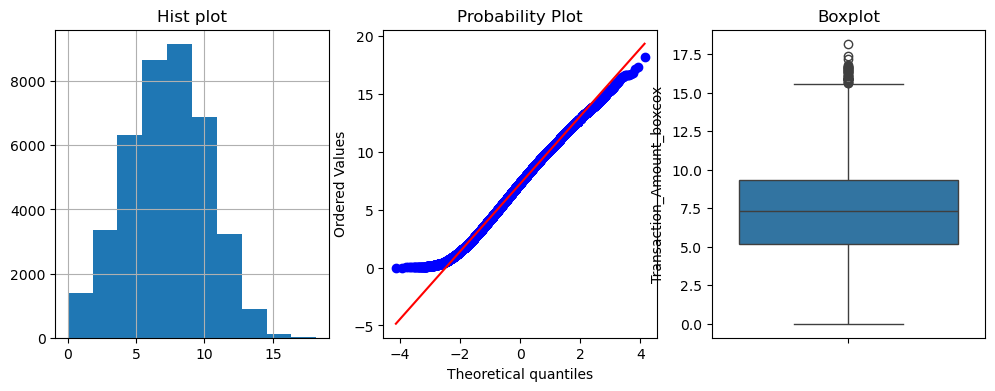

In [9]:
### checking with the graphs
plot_graphs(num_train_processed, ['Transaction_Amount_boxcox'])

In [10]:
### now the data looks good, but still checking for the outliers
check_outliers(num_train_processed, 'Transaction_Amount_boxcox')

'Q3 : 9.348318183033339 :: Q1 : 5.196802031065245 :: min : 0.0 :: max : 18.18037849923348 :: extreme upper value 21.80286663893762'

In [11]:
### from the above statement confirmed that there's no outliers, droppong of the old 'Transaction_Amount' column
drop_col(num_train_processed, 'Transaction_Amount')
num_train_processed.head()

,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,32068.28,0,0,5,112.75,4,142,3674.33,0.3668,0,1,4,13,16,7.716545
1,94961.81,0,0,8,199.95,1,32,796.99,0.4866,0,0,3,27,5,10.494160
2,39354.55,0,0,7,234.75,2,203,2286.33,0.2961,1,0,9,27,23,4.627272
3,46138.99,0,0,8,344.98,2,137,4924.98,0.3362,0,0,9,10,13,8.918271
4,52750.58,0,0,6,456.77,1,8,4924.36,0.0804,0,0,1,13,6,5.595966


In [12]:
### plotting the graphs again
# plot_graphs(num_train_processed, num_train_processed.columns)

In [13]:
### making the copy and applying the transformations to the copy dataset 
num_train_processed_copy = num_train_processed.copy()
num_train_processed_copy.head()

,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,32068.28,0,0,5,112.75,4,142,3674.33,0.3668,0,1,4,13,16,7.716545
1,94961.81,0,0,8,199.95,1,32,796.99,0.4866,0,0,3,27,5,10.494160
2,39354.55,0,0,7,234.75,2,203,2286.33,0.2961,1,0,9,27,23,4.627272
3,46138.99,0,0,8,344.98,2,137,4924.98,0.3362,0,0,9,10,13,8.918271
4,52750.58,0,0,6,456.77,1,8,4924.36,0.0804,0,0,1,13,6,5.595966


In [14]:
### applying the scaling to the original dataset
num_train_processed = apply_scaler(num_train_processed, scaler_path = None)
num_train_processed.head()

,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,0.317272,0,0,0.307692,0.209694,1.00,0.592437,0.734863,0.366737,0,1,0.272727,0.400000,0.695652,0.424444
1,0.949384,0,0,0.538462,0.387653,0.25,0.130252,0.159358,0.486549,0,0,0.181818,0.866667,0.217391,0.577225
2,0.390503,0,0,0.461538,0.458673,0.50,0.848739,0.457245,0.296030,1,0,0.727273,0.866667,1.000000,0.254520
3,0.458690,0,0,0.538462,0.683633,0.50,0.571429,0.985009,0.336134,0,0,0.727273,0.300000,0.565217,0.490544
4,0.525140,0,0,0.384615,0.911776,0.25,0.029412,0.984885,0.080308,0,0,0.000000,0.400000,0.260870,0.307802


In [15]:
### plotting the graphs and comparing the post scaling results
# plot_graphs_post_scaling(num_train_processed, num_train_processed_copy)

##### *********** Valid data *************

In [7]:
### setting up the path
num_valid_processed_path = '../data/intermidiate/num_valid_processed.csv'

In [8]:
### loading the data
num_valid_processed = load_data(num_valid_processed_path)
num_valid_processed.head()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour
0,19.98,1804.81,0,0,2,350.41,3,214,4568.48,0.6865,1,2,10,2
1,45.32,46648.03,0,1,11,47.14,1,78,297.39,0.5322,1,3,26,22
2,32.25,80244.56,0,0,7,160.14,2,59,4792.40,0.4924,0,8,5,12
3,35.41,24611.99,0,0,3,340.38,4,143,3318.08,0.5503,0,1,22,19
4,57.80,27154.09,1,0,1,149.80,0,227,573.20,0.2208,0,8,20,12


In [9]:
### checking the shape
get_shape(num_valid_processed)

(10000, 14)


In [10]:
### checking the nan values inside
get_nan_duplicates_shape(num_valid_processed)

shape : (10000, 14) 
duplicate values : 0 
Transaction_Amount              0
Account_Balance                 0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Age                        0
Transaction_Distance            0
Risk_Score                      0
Is_Weekend                      0
Timestamp_month                 0
Timestamp_day                   0
Timestamp_hour                  0
dtype: int64


In [20]:
### plotting the graphs (pre scaling)
# plot_graphs(num_valid_processed, cols = num_valid_processed.columns)

In [21]:
### applying the 'boxcox' transformation on the 'Transaction_Amount' column 
apply_boxcox(num_valid_processed, 'Transaction_Amount')
num_valid_processed.head()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,19.98,1804.81,0,0,2,350.41,3,214,4568.48,0.6865,1,2,10,2,4.436352
1,45.32,46648.03,0,1,11,47.14,1,78,297.39,0.5322,1,3,26,22,6.208881
2,32.25,80244.56,0,0,7,160.14,2,59,4792.40,0.4924,0,8,5,12,5.426819
3,35.41,24611.99,0,0,3,340.38,4,143,3318.08,0.5503,0,1,22,19,5.635001
4,57.80,27154.09,1,0,1,149.80,0,227,573.20,0.2208,0,8,20,12,6.810381


column : Transaction_Amount_boxcox


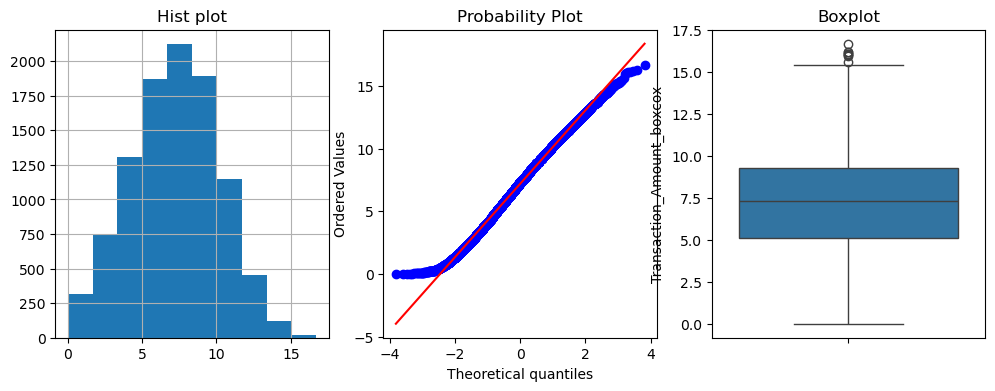

In [22]:
### checking the plots for the 'Transaction_Amount_boxcox'
plot_graphs(num_valid_processed, ['Transaction_Amount_boxcox'])

In [25]:
### we don't check for the outliers and neither remove them

In [24]:
### removing the old 'Transaction_Amount' column
drop_col(num_valid_processed, 'Transaction_Amount')
num_valid_processed.head()

,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,1804.81,0,0,2,350.41,3,214,4568.48,0.6865,1,2,10,2,4.436352
1,46648.03,0,1,11,47.14,1,78,297.39,0.5322,1,3,26,22,6.208881
2,80244.56,0,0,7,160.14,2,59,4792.40,0.4924,0,8,5,12,5.426819
3,24611.99,0,0,3,340.38,4,143,3318.08,0.5503,0,1,22,19,5.635001
4,27154.09,1,0,1,149.80,0,227,573.20,0.2208,0,8,20,12,6.810381


In [26]:
### making the copy of the data for the scaling
num_valid_processed_copy = num_valid_processed.copy()
num_valid_processed_copy.head()

,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,1804.81,0,0,2,350.41,3,214,4568.48,0.6865,1,2,10,2,4.436352
1,46648.03,0,1,11,47.14,1,78,297.39,0.5322,1,3,26,22,6.208881
2,80244.56,0,0,7,160.14,2,59,4792.40,0.4924,0,8,5,12,5.426819
3,24611.99,0,0,3,340.38,4,143,3318.08,0.5503,0,1,22,19,5.635001
4,27154.09,1,0,1,149.80,0,227,573.20,0.2208,0,8,20,12,6.810381


In [27]:
### giving the scaler path
scaler_path = '../scalers/scaler.pkl'

In [28]:
### applying the scaler on 'num_valid_processed'
num_valid_processed = apply_scaler(num_valid_processed, scaler_path = scaler_path)

In [29]:
### checking the scaled data
num_valid_processed.head()

,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,0.012998,0,0,0.076923,0.694722,0.75,0.894958,0.913818,0.686537,1,0.090909,0.300000,0.086957,0.265145
1,0.463744,0,1,0.769231,0.075779,0.25,0.323529,0.059363,0.532206,1,0.181818,0.833333,0.956522,0.371321
2,0.801443,0,0,0.461538,0.306400,0.50,0.243697,0.958614,0.492398,0,0.636364,0.133333,0.521739,0.324475
3,0.242247,0,0,0.153846,0.674252,1.00,0.596639,0.663668,0.550310,0,0.000000,0.700000,0.826087,0.336945
4,0.267799,1,0,0.000000,0.285297,0.00,0.949580,0.114540,0.220744,0,0.636364,0.633333,0.521739,0.407352


In [30]:
### plotting the graphs post scaling to compare the results
# plot_graphs_post_scaling(num_valid_processed, num_valid_processed_copy)s

##### ******** saving the data ***********

In [31]:
### setting up the paths to save the data
num_train_processed_scaled_path = '../data/intermidiate/num_train_processed_scaled.csv'
num_valid_processed_scaled_path = '../data/intermidiate/num_valid_processed_scaled.csv'

In [32]:
### saving the data
save_data(num_train_processed, num_train_processed_scaled_path)
save_data(num_valid_processed, num_valid_processed_scaled_path)

In [33]:
### checking the data, if everything was good
num_train_processed_scaled = load_data(num_train_processed_scaled_path)
num_train_processed_scaled.head()

,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,0.317272,0,0,0.307692,0.209694,1.00,0.592437,0.734863,0.366737,0,1,0.272727,0.400000,0.695652,0.424444
1,0.949384,0,0,0.538462,0.387653,0.25,0.130252,0.159358,0.486549,0,0,0.181818,0.866667,0.217391,0.577225
2,0.390503,0,0,0.461538,0.458673,0.50,0.848739,0.457245,0.296030,1,0,0.727273,0.866667,1.000000,0.254520
3,0.458690,0,0,0.538462,0.683633,0.50,0.571429,0.985009,0.336134,0,0,0.727273,0.300000,0.565217,0.490544
4,0.525140,0,0,0.384615,0.911776,0.25,0.029412,0.984885,0.080308,0,0,0.000000,0.400000,0.260870,0.307802


In [34]:
### checking the 'num_valid_processed_scaled'
num_valid_processed_scaled = load_data(num_valid_processed_scaled_path)
num_valid_processed_scaled.head()

,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,0.012998,0,0,0.076923,0.694722,0.75,0.894958,0.913818,0.686537,1,0.090909,0.300000,0.086957,0.265145
1,0.463744,0,1,0.769231,0.075779,0.25,0.323529,0.059363,0.532206,1,0.181818,0.833333,0.956522,0.371321
2,0.801443,0,0,0.461538,0.306400,0.50,0.243697,0.958614,0.492398,0,0.636364,0.133333,0.521739,0.324475
3,0.242247,0,0,0.153846,0.674252,1.00,0.596639,0.663668,0.550310,0,0.000000,0.700000,0.826087,0.336945
4,0.267799,1,0,0.000000,0.285297,0.00,0.949580,0.114540,0.220744,0,0.636364,0.633333,0.521739,0.407352
